# Zajęcia 1: LLM i embeddingi

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adrianstando/2026Z-PJATK-TEG/blob/main/01-llm-embeddingi/notebook.ipynb)

Zakres:
1. Konfiguracja dostępu do modelu.
2. Pierwsze wywołanie: system prompt i wiadomość użytkownika.
3. Zawartość odpowiedzi: tokeny, koszt, tokeny rozumowania.
4. Tokenizacja.
5. Parametry generowania: temperatura, `top_p`, limit długości.
6. Rozmowa z historią i prosty agent z narzędziami.
7. Embeddingi: podobieństwo, kontekst, klastry, analogie.
8. Mini-wyszukiwarka wektorowa, czyli podstawa RAG (zajęcia 2).

Komórki z tagiem `web:*` są pokazywane na prezentacji.

## 0. Instalacja i konfiguracja

In [1]:
# Colab / Deepnote / Codespaces: odkomentuj i uruchom raz
# %pip install -q openai tiktoken numpy scikit-learn matplotlib seaborn python-dotenv anthropic

Dostawcę wybiera się zmienną `LLM_PROVIDER` (plik `.env` albo w Colabie: ikona klucza → *Secrets*). Instrukcja konfiguracji dostępu: [00-dostep-do-llm](../00-dostep-do-llm/README.md).

| `LLM_PROVIDER` | Wymagania |
|---|---|
| `azure` | `AZURE_OPENAI_ENDPOINT`, `AZURE_OPENAI_API_KEY` i deploymenty modeli |
| `openai` | `OPENAI_API_KEY` |
| `deepseek` | `DEEPSEEK_API_KEY`; tanie API, bez embeddingów |
| `ollama` | [Ollama](https://ollama.com) lokalnie albo w Colabie na darmowym GPU (komórka niżej), modele `gemma4:e4b`, `gemma3:1b`, `embeddinggemma` |
| `proxy` | uruchomione [proxy dla subskrypcji](../tools/teg-proxy/README.md) (Copilot, Claude, Codex); bez embeddingów |

Wszyscy dostawcy udostępniają API zgodne z OpenAI, więc dalszy kod jest wspólny. Gdy dostawca nie liczy embeddingów, służy do tego `EMBED_PROVIDER` (domyślnie `ollama`).

### Ollama w Colabie (darmowe GPU)

Colab daje za darmo kartę graficzną NVIDIA T4, na której działa Ollama. Najpierw *Środowisko wykonawcze → Zmień typ środowiska wykonawczego → T4 GPU*, potem komórka poniżej (odkomentowana). Na początek wystarczy mały `gemma3:1b`; większy `gemma4:e4b` zajmuje ok. 10 GB. Bez niego w *Secrets* ustawia się `OLLAMA_CHAT=gemma3:1b`.

In [2]:
# Colab z GPU: odkomentuj i uruchom raz na sesję
# !nvidia-smi                                   # czy GPU jest włączone
# !sudo apt-get -qq install -y zstd pciutils > /dev/null
# !curl -fsSL https://ollama.com/install.sh | sh
# import subprocess
# subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
# !ollama pull gemma3:1b
# !ollama pull embeddinggemma
# !ollama pull gemma4:e4b                       # opcjonalnie, ~10 GB

In [3]:
import os

try:  # Colab: sekrety z panelu "Secrets"
    from google.colab import userdata
    for k in ["LLM_PROVIDER", "EMBED_PROVIDER", "OLLAMA_CHAT", "OPENAI_API_KEY", "AZURE_OPENAI_ENDPOINT",
              "AZURE_OPENAI_API_KEY", "DEEPSEEK_API_KEY", "ANTHROPIC_API_KEY"]:
        try:
            os.environ.setdefault(k, userdata.get(k))
        except Exception:
            pass
except ImportError:  # lokalnie: plik .env
    from dotenv import load_dotenv
    load_dotenv(override=True)

from openai import OpenAI, AzureOpenAI

# chat: model rozumujący, classic: model bez rozumowania, embed: model embeddingów.
# W Azure to NAZWY DEPLOYMENTÓW utworzonych w AI Foundry.
MODELS = {
    "openai":   {"chat": "gpt-5-nano", "classic": "gpt-4.1-mini", "embed": "text-embedding-3-small"},
    "azure":    {"chat": "gpt-5-nano", "classic": "gpt-4o-mini", "embed": "text-embedding-3-small"},
    "deepseek": {"chat": "deepseek-reasoner", "classic": "deepseek-chat", "embed": None},
    "ollama":   {"chat": os.getenv("OLLAMA_CHAT", "gemma4:e4b"), "classic": "gemma3:1b", "embed": "embeddinggemma"},
    "proxy":    {"chat": "copilot/gpt-5-mini", "classic": "copilot/gpt-5-mini", "embed": None},
}

def make_client(provider):
    if provider == "azure":
        return AzureOpenAI(api_version="2024-12-01-preview")  # AZURE_OPENAI_ENDPOINT + AZURE_OPENAI_API_KEY
    if provider == "deepseek":
        return OpenAI(base_url="https://api.deepseek.com", api_key=os.environ["DEEPSEEK_API_KEY"])
    if provider == "ollama":
        return OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")  # klucz wymagany, ale ignorowany
    if provider == "proxy":
        return OpenAI(base_url="http://localhost:8787/v1", api_key="teg")
    return OpenAI()  # OPENAI_API_KEY

PROVIDER = os.getenv("LLM_PROVIDER", "ollama")
EMBED_PROVIDER = os.getenv("EMBED_PROVIDER") or (PROVIDER if MODELS[PROVIDER]["embed"] else "ollama")

client = make_client(PROVIDER)
embed_client = client if EMBED_PROVIDER == PROVIDER else make_client(EMBED_PROVIDER)
CHAT, CLASSIC = MODELS[PROVIDER]["chat"], MODELS[PROVIDER]["classic"]
EMBED = MODELS[EMBED_PROVIDER]["embed"]
print(f"czat: {PROVIDER} ({CHAT}, klasyczny: {CLASSIC}) | embeddingi: {EMBED_PROVIDER} ({EMBED})")

czat: openai (gpt-5-nano, klasyczny: gpt-4.1-mini) | embeddingi: ollama (embeddinggemma)


`CHAT` to model **rozumujący**: przed odpowiedzią generuje ukryte tokeny rozumowania. `CLASSIC` to model bez rozumowania. Różnica ma znaczenie przy parametrach generowania (sekcja 4).

## 1. Pierwsze wywołanie

Rozmowa to lista wiadomości z rolami:
- `system`: instrukcja dla modelu (rola, ton, format odpowiedzi),
- `user`: wiadomość użytkownika,
- `assistant`: wcześniejsze odpowiedzi modelu.

In [4]:
response = client.chat.completions.create(
    model=CHAT,
    messages=[
        {"role": "system", "content": "You are a cool teacher who explains science using hip-hop slang."},
        {"role": "user", "content": "Why is the sky blue?"},
    ],
)
print(response.choices[0].message.content)

Yo, quick science beat on why the sky is blue:

- Sunlight ain’t just one color—it’s a mix, a white light.
- When that light hits Earth’s atmosphere, it runs into gas molecules and gets scattered in all directions. This is Rayleigh scattering.
- Shorter wavelengths (blue, violet) scatter way more than longer ones (red, orange). So blue light gets bounced around everywhere across the sky.
- But you don’t see a violet sky because: the sun isn’t pumping a ton of violet, our eyes are more sensitive to blue, and some violet gets absorbed by the atmosphere.

Sunrise/sunset twist: the Sun’s light has to travel through more air, so even more blue light gets scattered out of your line of sight. What you mostly see are those reds and oranges instead.

So the sky looks blue because the atmosphere scatter-kicks the blue light around, and our eyes catch that blue from every direction.


**Ćwiczenie.** Zmień system prompt (pirat, konsultant korporacyjny, przedszkolanka) i porównaj odpowiedzi na to samo pytanie. Następnie wymuś format: *„Odpowiadaj wyłącznie w JSON z polami `answer` i `confidence`”*.

## 2. Zawartość odpowiedzi

Odpowiedź to obiekt, a nie sam tekst. Najważniejsze pola:
- `choices[0].message.content`: treść,
- `choices[0].finish_reason`: `stop` (koniec odpowiedzi) albo `length` (wyczerpany limit tokenów),
- `usage`: zużycie tokenów, czyli podstawa rozliczenia.

In [5]:
u = response.usage
print("finish_reason:     ", response.choices[0].finish_reason)
print("prompt tokens:     ", u.prompt_tokens)
print("completion tokens: ", u.completion_tokens)
details = getattr(u, "completion_tokens_details", None)
print("reasoning tokens:  ", getattr(details, "reasoning_tokens", None))

finish_reason:      stop
prompt tokens:      29
completion tokens:  1227
reasoning tokens:   1024


W modelach rozumujących `completion_tokens` obejmuje także tokeny rozumowania (`reasoning_tokens`), których nie widać w odpowiedzi. Rozliczane są wszystkie. Nie każdy dostawca raportuje `reasoning_tokens` (np. Ollama zwraca `None`).

## 3. Tokeny

Model nie przetwarza liter ani słów, tylko **tokeny**: fragmenty tekstu ze słownika tokenizera. Modele GPT-4o i GPT-5 używają tokenizera `o200k_base` (ok. 200 tys. tokenów). Słownik powstał na korpusie zdominowanym przez angielski, dlatego angielskie słowa częściej są pojedynczymi tokenami, a polski tekst dzieli się na więcej fragmentów. Ten sam tekst po polsku jest droższy i zajmuje więcej miejsca w oknie kontekstu.

In [6]:
import tiktoken

enc = tiktoken.get_encoding("o200k_base")
for text in ["Language models predict the next token.",
             "Modele językowe przewidują kolejny token.",
             "Konstantynopolitańczykowianeczka"]:
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    print(f"{len(text):3d} znaków -> {len(ids):2d} tokenów | {pieces}")

 39 znaków ->  7 tokenów | ['Language', ' models', ' predict', ' the', ' next', ' token', '.']
 41 znaków -> 12 tokenów | ['Mode', 'le', ' ję', 'zyk', 'owe', ' przew', 'id', 'ują', ' kolej', 'ny', ' token', '.']
 32 znaków -> 10 tokenów | ['Kon', 'stant', 'yn', 'opol', 'ita', 'ńczy', 'kow', 'ian', 'ecz', 'ka']


**Ćwiczenie.** Policz tokeny dla własnego imienia i nazwiska, fragmentu kodu w Pythonie i emoji 🙂. Który tekst jest najdroższy w przeliczeniu na znak?

In [ ]:
# Podstaw własne imię i nazwisko. Tokenizer `enc` jest z komórki wyżej.
samples = {
    "imię i nazwisko": "Grzegorz Brzęczyszczykiewicz",
    "kod w Pythonie": "def square(x):\n    return x ** 2",
    "emoji": "🙂",
}
for label, text in samples.items():
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    print(f"{label:<16} {len(text):3d} znaków -> {len(ids):2d} tokenów | {len(ids) / len(text):.2f} tokenu na znak")
    print(f"{'':<16} {pieces}")

imię i nazwisko   28 znaków -> 11 tokenów | 0.39 tokenu na znak
                 ['Gr', 'zeg', 'orz', ' Br', 'zę', 'cz', 'ys', 'zc', 'zyk', 'iew', 'icz']
kod w Pythonie    32 znaków -> 10 tokenów | 0.31 tokenu na znak
                 ['def', ' square', '(x', '):\n', '   ', ' return', ' x', ' **', ' ', '2']
emoji              1 znaków ->  1 tokenów | 1.00 tokenu na znak
                 ['🙂']


Najdroższe na znak jest emoji: jeden znak, ale cały token (w UTF-8 to 4 bajty). Rzadsze emoji i znaki spoza słownika dzielą się nawet na kilka tokenów. Polskie nazwisko jest droższe od kodu, bo „ę” i zbitki „szcz”, „cz” rzadko występują w korpusie tokenizera. Kod w Pythonie jest tani: słowa kluczowe i typowe ciągi (`):\n`, ` return`) są pojedynczymi tokenami, a cztery spacje wcięcia zajmują tylko dwa tokeny (trzy spacje plus spacja doklejona do `return`).

## 4. Parametry generowania

W każdym kroku model wyznacza rozkład prawdopodobieństwa kolejnego tokenu i z niego losuje. Parametry zmieniają ten rozkład:
- `temperature`: mała wartość wyostrza rozkład (prawie zawsze najbardziej prawdopodobny token), duża go spłaszcza,
- `top_p`: losowanie tylko spośród najbardziej prawdopodobnych tokenów, których łączne prawdopodobieństwo wynosi `p`,
- `top_k` (Ollama, Anthropic; brak w API OpenAI): losowanie tylko spośród `k` najbardziej prawdopodobnych tokenów.

Zalecenie OpenAI: zmieniać **albo** `temperature`, **albo** `top_p`. Interaktywna wersja wszystkich trzech parametrów jest na prezentacji.

> **Uwaga.** Modele rozumujące (gpt-5*, seria o, Claude Opus 5.5) nie przyjmują `temperature` ani `top_p` i zwracają błąd 400. Poniżej używany jest więc `CLASSIC`.

In [7]:
for temp in [0.0, 1.0, 1.6]:
    out = client.chat.completions.create(
        model=CLASSIC,
        messages=[{"role": "user", "content": "Describe a sunset in one creative sentence."}],
        temperature=temp,
    )
    print(f"T={temp}: {out.choices[0].message.content.strip()}\n")

T=0.0: The sun dipped behind the horizon like a molten ember melting into a sea of liquid gold and lavender whispers.



T=1.0: The sun dipped behind the horizon like a glowing ember melting into a sea of molten gold and lavender whispers.



T=1.6: The horizon blushed as molten gold slipped beneath veins of crimson and lavender twilight, bidding the day a fiery, tender farewell.



Po kilkukrotnym uruchomieniu komórki: przy `T=0` odpowiedzi są (prawie) identyczne, przy `T=1.6` za każdym razem inne, a czasem bez sensu.

Ten sam parametr przekazany do modelu rozumującego (np. `gpt-5-nano`) kończy się błędem 400. Ollama go nie odrzuca, tylko przekazuje do modelu.

### Limit długości odpowiedzi

Limit tokenów ucina odpowiedź. Model nie wie o limicie, więc nie skraca odpowiedzi, tylko zostaje przerwany (`finish_reason == "length"`). Krótszą odpowiedź lepiej uzyskać instrukcją w prompcie.

W modelach rozumujących limit obejmuje **również tokeny rozumowania**. Przy zbyt niskim limicie rozumowanie może go wyczerpać, zanim powstanie jakakolwiek treść, i odpowiedź będzie pusta. Nowsze modele same dobierają długość rozumowania do trudności zadania (*adaptive thinking* w Claude, *reasoning effort* w GPT-5), ale limit nadal liczy wszystkie tokeny.

Nazwa parametru zależy od API:

| API | Parametr |
|---|---|
| OpenAI Chat Completions (także Azure, GitHub Models) | `max_completion_tokens` (stary `max_tokens` jest odrzucany przez modele rozumujące) |
| OpenAI Responses API | `max_output_tokens` |
| Anthropic | `max_tokens` (wymagany) |
| Ollama (API zgodne z OpenAI) | `max_tokens`; `max_completion_tokens` jest ignorowany |

In [8]:
LIMIT_PARAM = "max_tokens" if PROVIDER == "ollama" else "max_completion_tokens"

for limit in [15, 300, 2000]:
    out = client.chat.completions.create(
        model=CHAT,
        messages=[{"role": "user", "content": "Explain machine learning in one short sentence."}],
        **{LIMIT_PARAM: limit},
    )
    c, u = out.choices[0], out.usage
    reasoning = getattr(u.completion_tokens_details, "reasoning_tokens", None) if u.completion_tokens_details else None
    print(f"limit={limit:<5} finish_reason={c.finish_reason:<7} tokeny={u.completion_tokens:<5} rozumowanie={reasoning}")
    print(f"   {c.message.content!r}\n")

limit=15    finish_reason=length  tokeny=15    rozumowanie=15
   ''



limit=300   finish_reason=stop    tokeny=285   rozumowanie=256
   'Machine learning is teaching computers to improve at tasks by learning patterns from data rather than being explicitly programmed.'



limit=2000  finish_reason=stop    tokeny=220   rozumowanie=192
   'Machine learning is teaching computers to improve at tasks by learning from data rather than following explicit instructions.'



## 5. Rozmowa z historią

API jest **bezstanowe**: model nie pamięta poprzednich wywołań. Pamięć rozmowy to lista wiadomości, którą przy każdym wywołaniu trzeba wysłać od nowa. Z tego powodu długa rozmowa kosztuje coraz więcej.

In [9]:
history = [{"role": "system", "content": "Jesteś asystentem na zajęciach z AI. Odpowiadasz krótko, po polsku."}]

def chat(user_message):
    history.append({"role": "user", "content": user_message})
    reply = client.chat.completions.create(model=CHAT, messages=history).choices[0].message.content
    history.append({"role": "assistant", "content": reply})
    return reply

print(chat("Cześć, mam na imię Ola i interesują mnie grafy wiedzy."))
print(chat("Jak mam na imię i co mnie interesuje?"))
print(f"\nwiadomości w historii: {len(history)}")

Cześć Ola! Miło Cię poznać.

Krótko o grafach wiedzy:
- encje (wierzchołki) i relacje między nimi (krawędziami);
- zapisane jako trójki S-P-O (np. Ola - interesuje - grafy_wiedzy);
- używa się RDF/OWL do opisu, SPARQL do zapytań.

Chcesz: 
- prosty przykład danych RDF/Turtle i zapytanie SPARQL, 
- czy wyjaśnienie różnic RDF/OWL, 
- czy ćwiczenie praktyczne?


Masz na imię Ola i interesują Cię grafy wiedzy. Co chcesz zrobić dalej? np. przykład RDF/Turtle i SPARQL, wyjaśnienie RDF/OWL, czy ćwiczenie praktyczne?

wiadomości w historii: 5


## 6. Prosty agent

Model nie zna dzisiejszej daty i nie liczy niezawodnie. Może jednak poprosić o wywołanie funkcji (*tool calling*): zwraca nazwę funkcji i argumenty, a kod je wykonuje i odsyła wynik. Agent to pętla: model → narzędzie → model, dopóki model nie odpowie tekstem.

Więcej o agentach na zajęciach 3.

In [10]:
import json
from datetime import date

def get_today() -> str:
    return date.today().isoformat()

def days_between(start: str, end: str) -> int:
    return (date.fromisoformat(end) - date.fromisoformat(start)).days

TOOLS = {"get_today": get_today, "days_between": days_between}
TOOL_SPECS = [
    {"type": "function", "function": {"name": "get_today", "description": "Dzisiejsza data (YYYY-MM-DD).",
                                      "parameters": {"type": "object", "properties": {}}}},
    {"type": "function", "function": {"name": "days_between", "description": "Liczba dni między datami (YYYY-MM-DD).",
                                      "parameters": {"type": "object", "properties": {"start": {"type": "string"}, "end": {"type": "string"}},
                                                     "required": ["start", "end"]}}},
]

def agent(question, max_steps=5):
    messages = [{"role": "user", "content": question}]
    for step in range(1, max_steps + 1):
        msg = client.chat.completions.create(model=CHAT, messages=messages, tools=TOOL_SPECS).choices[0].message
        if not msg.tool_calls:          # model odpowiada tekstem: koniec pętli
            return msg.content
        messages.append(msg.model_dump(exclude_none=True))
        for call in msg.tool_calls:     # model prosi o narzędzia: wykonanie i odesłanie wyników
            args = json.loads(call.function.arguments or "{}")
            result = TOOLS[call.function.name](**args)
            print(f"krok {step}: {call.function.name}({args}) -> {result}")
            messages.append({"role": "tool", "tool_call_id": call.id, "content": str(result)})
    return "Przekroczono limit kroków."

print(agent("Ile dni zostało do Wigilii 2026?"))

krok 1: days_between({'start': '2026-10-02', 'end': '2026-12-24'}) -> 83


Do Wigilii 2026 zostało 83 dni.


## 7. Inny dostawca: Anthropic (Claude)

API Anthropic ma inny kształt: `system` jest osobnym parametrem, `max_tokens` jest wymagany, a treść odpowiedzi znajduje się w `content[0].text`. Komórka wykona się tylko przy ustawionym `ANTHROPIC_API_KEY`; zapisany wynik pochodzi z `claude-opus-5-5`. Pozostałe przykłady (Claude Agent SDK, Codex, Copilot SDK) są w [00-dostep-do-llm](../00-dostep-do-llm/README.md).

In [11]:
if os.getenv("ANTHROPIC_API_KEY"):
    import anthropic

    claude = anthropic.Anthropic()
    msg = claude.messages.create(
        model="claude-opus-5-5",
        max_tokens=1024,
        system="You are a cool teacher who explains science using hip-hop slang.",
        messages=[{"role": "user", "content": "Why is the sky blue?"}],
    )
    print(msg.content[0].text)
else:
    print("Brak ANTHROPIC_API_KEY, komórka pominięta.")

Yo, pull up a seat, class is in session 🎤

Sunlight comes through lookin' plain white, but that's a whole crew rollin' deep: red, orange, yellow, green, blue, violet, every color in the spectrum.

When that light hits the atmosphere, it runs into nitrogen and oxygen molecules, tiny compared to the light waves. Here's the science drop: **Rayleigh scattering**. Short wavelengths like blue get bounced around WAY harder than the long ones like red. We talkin' roughly 1/λ⁴, so blue scatters about five times more than red. Big facts.

So blue light gets ping-ponged all over the sky, and from wherever you look up, blue is comin' at you from every direction. That's why the sky is rockin' that fresh blue fit.

"But yo, violet's even shorter, why ain't the sky purple?" Good question, real one:
1. The sun puts out less violet than blue.
2. Some violet gets soaked up high in the atmosphere.
3. Your eyes are way more tuned to blue than violet.

Bonus track: at sunset the light travels through way m

---
# Embeddingi

Model embeddingów zamienia tekst na wektor liczb o stałej długości. Teksty o podobnym znaczeniu dają wektory skierowane w podobną stronę. Na tym opiera się wyszukiwanie semantyczne, RAG, rekomendacje i klasteryzacja.

| Model | Dostawca | Wymiar |
|---|---|---|
| `text-embedding-3-small` | OpenAI / Azure / GitHub Models | 1536 |
| `embeddinggemma` | Ollama (lokalnie) | 768 |

In [12]:
import numpy as np

_cache = {}

def embed(texts):
    """Embeddingi dla listy tekstów (z cache, żeby nie płacić dwa razy za to samo)."""
    todo = [t for t in texts if t not in _cache]
    if todo:
        resp = embed_client.embeddings.create(model=EMBED, input=todo)
        for t, d in zip(todo, resp.data):
            _cache[t] = np.array(d.embedding)
    return np.array([_cache[t] for t in texts])

def get_embedding(text):
    return embed([text])[0]

v = get_embedding("cat")
print("wymiar:        ", len(v))
print("pierwsze 5:    ", np.round(v[:5], 4))
print("długość (norm):", round(float(np.linalg.norm(v)), 4))

wymiar:         768
pierwsze 5:     [-0.2113  0.0116  0.0427  0.0268  0.0036]
długość (norm): 1.0


Długość wektora wynosi 1, bo dostawcy normalizują embeddingi. Dla takich wektorów cosinus jest równy iloczynowi skalarnemu (`a @ b`), a odległość euklidesowa niesie tę samą informację: kwadrat odległości to `2 − 2·cos(a, b)`.

## 8. Miary podobieństwa

In [13]:
def cos(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [("cat", "dog"), ("cat", "kitten"), ("king", "queen"), ("man", "woman"),
         ("happy", "joyful"), ("car", "automobile"), ("bratwurst", "sushi")]
print(f"{'para':<20}{'cosinus':>9}{'iloczyn':>9}{'euklides':>10}")
for a, b in pairs:
    va, vb = get_embedding(a), get_embedding(b)
    print(f"{a + ' - ' + b:<20}{cos(va, vb):>9.4f}{va @ vb:>9.4f}{np.linalg.norm(va - vb):>10.4f}")

para                  cosinus  iloczyn  euklides
cat - dog              0.7570   0.7570    0.6971


cat - kitten           0.8856   0.8856    0.4784


king - queen           0.7331   0.7331    0.7306


man - woman            0.7162   0.7162    0.7534


happy - joyful         0.9285   0.9285    0.3782


car - automobile       0.9145   0.9145    0.4135


bratwurst - sushi      0.6410   0.6410    0.8473


Nawet „bratwurst” i „sushi” mają dodatni cosinus. W praktyce liczy się **ranking** (co jest bliżej czego), a nie konkretna wartość, która zależy od modelu.

### Cosinus a odległość cosinusowa

- **Podobieństwo cosinusowe** `cos(a, b)` ma zakres od −1 do 1: 1 to ten sam kierunek, 0 to wektory prostopadłe, −1 to przeciwne.
- **Odległość cosinusowa** to `1 − cos(a, b)`, z zakresem od 0 do 2. Tak liczą ją `scipy`, `scikit-learn` i bazy wektorowe (np. Chroma z `cosine`). Nie jest znormalizowana do 0–1.

Ujemny cosinus łatwo pokazać na wektorach zapisanych ręcznie. W embeddingach tekstu prawie się nie zdarza: nawet słowa o przeciwnym znaczeniu („hot” i „cold”) występują w podobnych kontekstach, więc ich wektory są blisko.

In [14]:
from scipy.spatial.distance import cosine as cosine_distance

toy = {"ten sam kierunek": ([1, 2], [2, 4]), "prostopadłe": ([1, 0], [0, 1]),
       "rozwarty kąt": ([1, 0], [-1, 1]), "przeciwne": ([1, 2], [-1, -2])}
print(f"{'wektory':<18}{'cosinus':>9}{'odległość cos':>15}")
for name, (a, b) in toy.items():
    print(f"{name:<18}{cos(a, b):>9.3f}{cosine_distance(a, b):>15.3f}")

va, vb = get_embedding("hot"), get_embedding("cold")
print(f"\nhot - cold ({EMBED}): cosinus {cos(va, vb):.3f}, odległość {cosine_distance(va, vb):.3f}")

wektory             cosinus  odległość cos
ten sam kierunek      1.000          0.000
prostopadłe           0.000          1.000
rozwarty kąt         -0.707          1.707
przeciwne            -1.000          2.000



hot - cold (embeddinggemma): cosinus 0.684, odległość 0.316


## 9. Kontekst

Porównanie: słowo „cat” samo i w zdaniach, w dwóch modelach embeddingów. Komórka liczy wyniki dla modeli, które są dostępne (Ollama, klucz OpenAI albo oba); pozostałe pomija.

In [15]:
def embedder(provider, model):
    """Funkcja tekst(y) -> wektory dla wybranego modelu (z osobnym cache)."""
    cli, cache = make_client(provider), {}
    def f(texts):
        todo = [t for t in texts if t not in cache]
        if todo:
            for t, d in zip(todo, cli.embeddings.create(model=model, input=todo).data):
                cache[t] = np.array(d.embedding)
        return np.array([cache[t] for t in texts])
    return f

EMBEDDERS = {}
for provider, model in [("ollama", "embeddinggemma"), ("openai", "text-embedding-3-small")]:
    try:
        EMBEDDERS[model] = embedder(provider, model)
        EMBEDDERS[model](["test"])
    except Exception as e:
        EMBEDDERS.pop(model)
        print(f"{model}: pominięty ({type(e).__name__})")
print("modele do porównań:", ", ".join(EMBEDDERS))

modele do porównań: embeddinggemma, text-embedding-3-small


In [16]:
templates = ["{}", "The {} is sleeping peacefully", "I love my {} very much", "Training a {} requires patience"]
for name, emb in EMBEDDERS.items():
    print(f"{name}\n{'kontekst':<34}{'cat-dog':>9}{'cat-kitten':>12}")
    for t in templates:
        c, d, k = emb([t.format(w) for w in ["cat", "dog", "kitten"]])
        print(f"{t.replace('{}', '[X]'):<34}{cos(c, d):>9.4f}{cos(c, k):>12.4f}")
    print()

embeddinggemma
kontekst                            cat-dog  cat-kitten
[X]                                  0.7570      0.8856


The [X] is sleeping peacefully       0.7930      0.9157
I love my [X] very much              0.8758      0.9531


Training a [X] requires patience     0.8341      0.9408

text-embedding-3-small
kontekst                            cat-dog  cat-kitten


[X]                                  0.6027      0.5696
The [X] is sleeping peacefully       0.7670      0.8822


I love my [X] very much              0.7761      0.9080
Training a [X] requires patience     0.7803      0.9055



Wnioski:
- relacje między słowami zależą od modelu: embedding odzwierciedla użycie słów w danych treningowych konkretnego modelu,
- zmiana modelu oznacza ponowne policzenie embeddingów całej bazy,
- w RAG embeddingi liczy się dla **fragmentów tekstu** (chunków), a nie pojedynczych słów.

## 10. Klastry: rzut na 2D

Wektora o 768 czy 1536 wymiarach nie da się narysować, dlatego rzutuje się go na 2D:
- **PCA**: rzut liniowy; szybki, ale zwykle zachowuje niewielką część wariancji, więc grupy się nakładają,
- **t-SNE**: rzut nieliniowy; zachowuje sąsiedztwa i dobrze pokazuje klastry, ale **odległości między klastrami i ich rozmiary nie mają znaczenia**.

Podobieństwo liczy się zawsze na **pełnych wektorach**. Rzut 2D służy wyłącznie do wizualizacji.

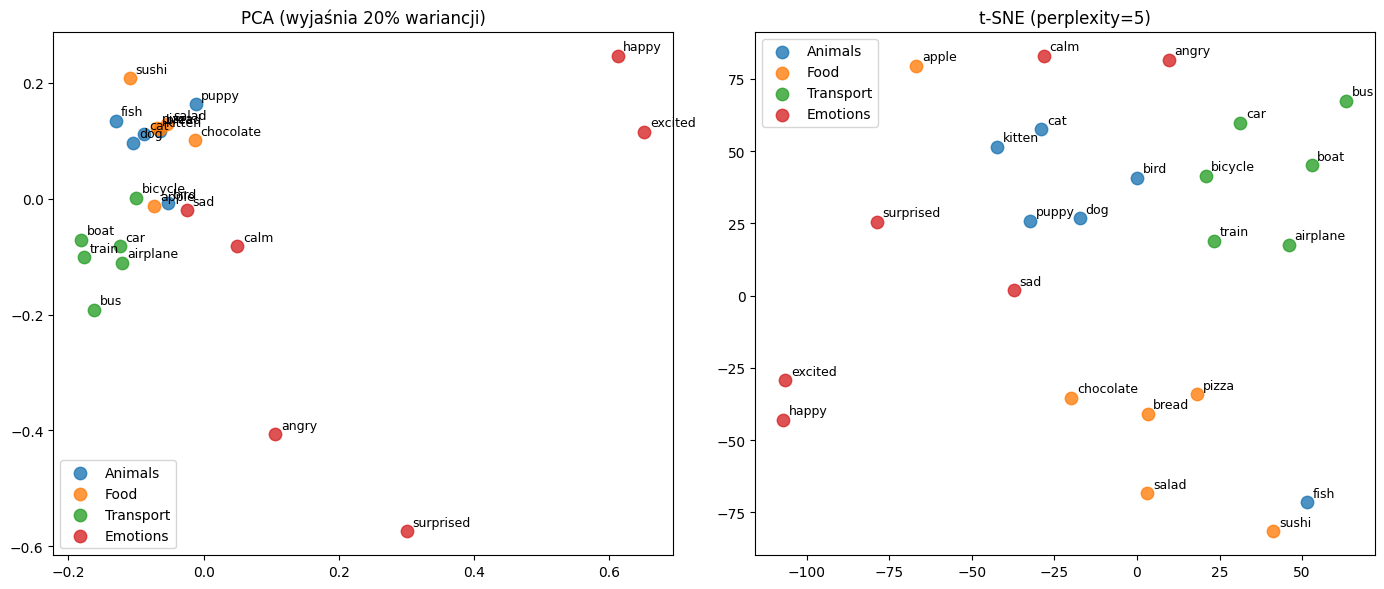

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

groups = {
    "Animals": ["cat", "dog", "kitten", "puppy", "bird", "fish"],
    "Food": ["apple", "pizza", "sushi", "bread", "chocolate", "salad"],
    "Transport": ["car", "bicycle", "airplane", "train", "boat", "bus"],
    "Emotions": ["happy", "sad", "angry", "excited", "calm", "surprised"],
}
words = [w for ws in groups.values() for w in ws]
labels = [g for g, ws in groups.items() for _ in ws]
X = embed(words)

pca = PCA(n_components=2).fit(X)
projections = {
    f"PCA (wyjaśnia {pca.explained_variance_ratio_.sum():.0%} wariancji)": pca.transform(X),
    "t-SNE (perplexity=5)": TSNE(n_components=2, perplexity=5, metric="cosine", init="pca", random_state=0).fit_transform(X),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (title, P) in zip(axes, projections.items()):
    for g in groups:
        idx = [i for i, l in enumerate(labels) if l == g]
        ax.scatter(P[idx, 0], P[idx, 1], s=80, alpha=0.8, label=g)
        for i in idx:
            ax.annotate(words[i], P[i], fontsize=9, xytext=(4, 4), textcoords="offset points")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
S = X @ X.T  # wektory znormalizowane, więc to macierz cosinusów
same = [S[i, j] for i in range(len(words)) for j in range(i + 1, len(words)) if labels[i] == labels[j]]
diff = [S[i, j] for i in range(len(words)) for j in range(i + 1, len(words)) if labels[i] != labels[j]]
print(f"średni cosinus w tej samej grupie: {np.mean(same):.3f}")
print(f"średni cosinus między grupami:     {np.mean(diff):.3f}")

średni cosinus w tej samej grupie: 0.615
średni cosinus między grupami:     0.558


## 11. Mapa podobieństw

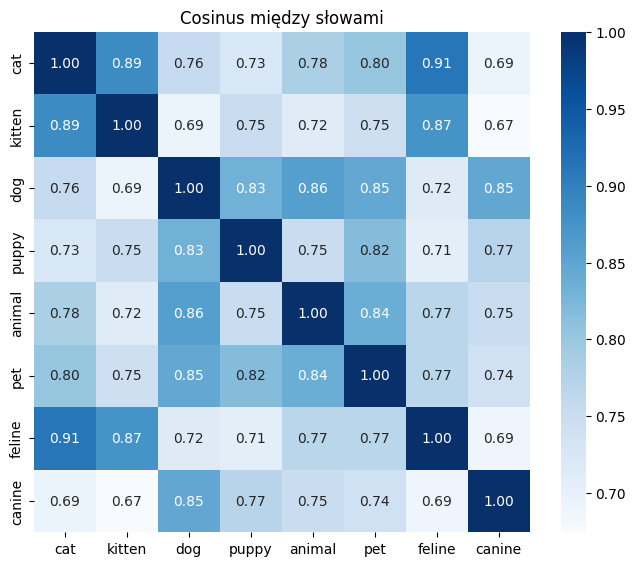

In [19]:
import seaborn as sns

hw = ["cat", "kitten", "dog", "puppy", "animal", "pet", "feline", "canine"]
H = embed(hw)
plt.figure(figsize=(8, 6.5))
sns.heatmap(H @ H.T, annot=True, fmt=".2f", xticklabels=hw, yticklabels=hw, cmap="Blues")
plt.title("Cosinus między słowami")
plt.show()

## 12. Arytmetyka wektorów: king − man + woman ≈ queen?

Klasyczny przykład z word2vec. W nowszych modelach działa słabiej, niż sugerują podręczniki: najbliżej wyniku jest zwykle jedno ze słów wejściowych („king”), dlatego standardowo wyklucza się je z rankingu. Porównanie dwóch modeli embeddingów:

In [20]:
def analogy(emb, a, b, c, candidates):
    """a - b + c ≈ ?  (np. king - man + woman)"""
    va, vb, vc = emb([a, b, c])
    target = va - vb + vc
    return sorted(zip(candidates, (cos(target, v) for v in emb(candidates))), key=lambda x: -x[1])

cands = ["queen", "king", "woman", "princess", "lady", "ruler", "empress", "monarch", "prince"]
for name, emb in EMBEDDERS.items():
    print(name)
    for w, s in analogy(emb, "king", "man", "woman", cands):
        print(f"   {w:<10}{s:.4f}")
    print()

embeddinggemma


   king      0.7640
   queen     0.7031
   woman     0.6594
   lady      0.5894
   princess  0.5749
   monarch   0.5267
   ruler     0.5033
   prince    0.4490
   empress   0.3281

text-embedding-3-small


   king      0.7637
   queen     0.6162
   woman     0.6024
   princess  0.4646
   lady      0.4468
   ruler     0.4336
   empress   0.4264
   monarch   0.4001
   prince    0.3906



## 13. Mini-wyszukiwarka wektorowa

Tak działa każda baza wektorowa, tylko bez optymalizacji:
1. embedding dokumentów (raz),
2. embedding zapytania,
3. cosinus z **każdym** dokumentem i wybór `k` najlepszych.

Bazy wektorowe (Chroma, FAISS, pgvector) zastępują krok 3 przybliżonym wyszukiwaniem (ANN), żeby nie porównywać zapytania z milionem wektorów po kolei.

In [21]:
docs = [
    "Maria Skłodowska-Curie jako pierwsza osoba otrzymała dwie Nagrody Nobla w dwóch różnych dziedzinach.",
    "Skłodowska odkryła polon i rad, a polon nazwała na cześć Polski.",
    "Einstein sformułował szczególną teorię względności w 1905 roku.",
    "Równanie E = mc² opisuje równoważność masy i energii.",
    "Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.",
    "Ada Lovelace napisała pierwszy algorytm przeznaczony dla maszyny analitycznej Babbage'a.",
    "Darwin opisał ewolucję drogą doboru naturalnego w dziele O powstawaniu gatunków.",
    "Darwin przez lata badał dżdżownice i ich wpływ na glebę.",
]
D = embed(docs)

def search(query, k=3):
    q = get_embedding(query)
    scores = D @ q / (np.linalg.norm(D, axis=1) * np.linalg.norm(q))
    best = np.argsort(-scores)[:k]
    return [(round(float(scores[i]), 3), docs[i]) for i in best]

for q in ["Kto dostał dwa Noble?", "Dlaczego jabłko spada na ziemię?"]:
    print("Q:", q)
    for s, d in search(q):
        print(f"   {s:.3f}  {d}")

Q: Kto dostał dwa Noble?
   0.522  Maria Skłodowska-Curie jako pierwsza osoba otrzymała dwie Nagrody Nobla w dwóch różnych dziedzinach.
   0.270  Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.
   0.213  Skłodowska odkryła polon i rad, a polon nazwała na cześć Polski.
Q: Dlaczego jabłko spada na ziemię?


   0.416  Darwin przez lata badał dżdżownice i ich wpływ na glebę.
   0.322  Darwin opisał ewolucję drogą doboru naturalnego w dziele O powstawaniu gatunków.
   0.314  Newton opisał prawo powszechnego ciążenia i trzy zasady dynamiki.


W drugim pytaniu Newton nie musi być na pierwszym miejscu. Model embeddingów łączy podobne słowa („ziemia” i „gleba”), ale nie rozumie pytania. Na zajęciach 2 pojawią się poprawki:
- **wyszukiwanie hybrydowe**: embeddingi + BM25 (słowa kluczowe),
- **reranking**: drugi model ocenia pary (pytanie, fragment).

**Ćwiczenie.** Dopisz 5 dokumentów i 3 pytania z wybranej dziedziny. Znajdź pytanie, na które wyszukiwarka odpowiada źle, i wyjaśnij, dlaczego.

## Zadanie

Zadanie po zajęciach: [zadanie.ipynb](zadanie.ipynb) ([Colab](https://colab.research.google.com/github/adrianstando/2026Z-PJATK-TEG/blob/main/01-llm-embeddingi/zadanie.ipynb)).